# Phase 2 — Multi-scale Seasonality Analysis

Daily, weekly, monthly/yearly patterns. STL decomposition.

In [1]:
import sys
sys.path.insert(0, '..')
import pandas as pd
import plotly.express as px
from statsmodels.tsa.seasonal import STL

from src.data.loader import load_processed

In [2]:
df = load_processed()
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [3]:
# Daily pattern: average consumption by hour of day
hourly = df.groupby(df.index.hour)['Global_active_power'].mean()
px.line(hourly, title='Average Global Active Power by Hour of Day')

In [4]:
# Weekly pattern: average by day of week (0=Mon)
weekly = df.groupby(df.index.dayofweek)['Global_active_power'].mean()
px.bar(weekly, title='Average Global Active Power by Day of Week')

In [5]:
# Monthly / yearly pattern
monthly = df.resample('ME')['Global_active_power'].mean()
px.line(monthly, title='Monthly Average Global Active Power (trend + yearly seasonality)')

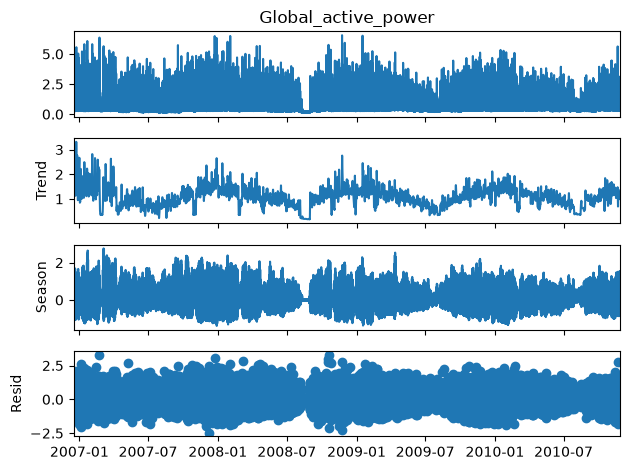

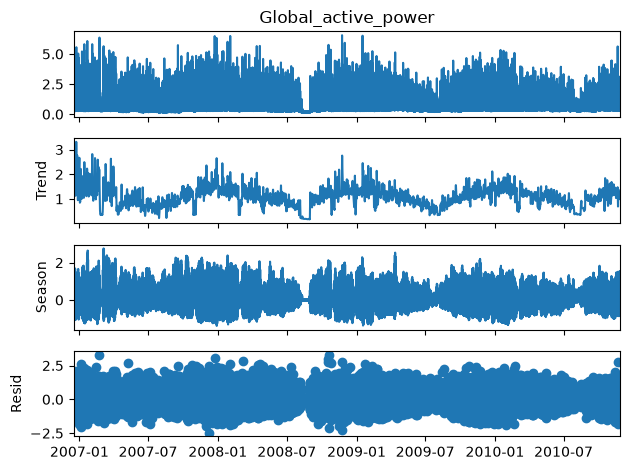

In [6]:
# STL decomposition on an hourly-resampled series (daily period = 24)
hourly_series = df['Global_active_power'].resample('h').mean().dropna()
stl = STL(hourly_series, period=24)
result = stl.fit()
result.plot()

## Write-up

'The decomposition revealed a dominant daily cycle, a secondary weekly cycle, and a [describe trend], suggesting [your hypothesis].'